In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("/Users/serhatguldogan/Library/CloudStorage/OneDrive-KocUniversitesi/Project_/RAW DATA/BTC_1sec.csv")


In [6]:
df.head()


,Unnamed: 0,system_time,midpoint,spread,buys,sells,bids_distance_0,bids_distance_1,bids_distance_2,bids_distance_3,...,asks_market_notional_5,asks_market_notional_6,asks_market_notional_7,asks_market_notional_8,asks_market_notional_9,asks_market_notional_10,asks_market_notional_11,asks_market_notional_12,asks_market_notional_13,asks_market_notional_14
0,0,2021-04-07 11:32:42.122161+00:00,56035.995,0.01,0.0,0.0,-8.922836e-08,-2.676851e-07,-0.00005,-0.000245,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,2021-04-07 11:32:43.122161+00:00,56035.995,0.01,0.0,0.0,-8.922836e-08,-2.676851e-07,-0.00005,-0.000245,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,2021-04-07 11:32:44.122161+00:00,56035.995,0.01,0.0,0.0,-8.922836e-08,-2.676851e-07,-0.00005,-0.000245,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,2021-04-07 11:32:45.122161+00:00,56035.995,0.01,0.0,0.0,-8.922836e-08,-2.676851e-07,-0.00005,-0.000245,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,2021-04-07 11:32:46.122161+00:00,56035.995,0.01,0.0,0.0,-8.922836e-08,-2.676851e-07,-0.00005,-0.000245,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
prices = np.array(df["midpoint"])


In this notebook, we make preparations to transition from fixed tick sizes to adjusted tick sizes. For this, we keep track of how much the price changes, and how many times the price change, given the price change magnitude.

In [8]:
d = dict()
for i in range(len(prices)-1):
    diff = prices[i+1] - prices[i]
    if diff in d:
        d[diff] += 1
    else:
        d[diff] = 1




Of course, delete the 0-price change instances, since we are only concerned about the nontrivial price changes.

In [ ]:
sorted_keys = sorted(d.keys())
d_ordered = {k: d[k] for k in sorted_keys}
d_new = d_ordered.copy()
d_new.pop(0)


611855

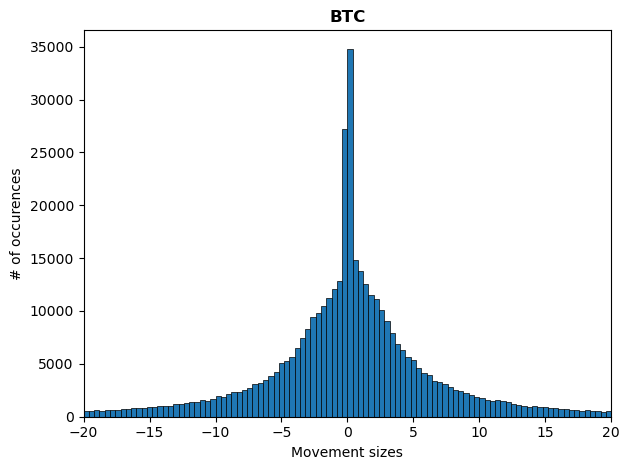

In [ ]:
center_min = -20  # Set your own center window here
center_max = 20  # Set your own center window here
centered_data = [k for k in d_new.keys() if center_min <= k <= center_max for _ in range(d[k])]
plt.hist(centered_data, bins=100, edgecolor='black', linewidth=0.5)
plt.xlim(center_min, center_max)



plt.xlabel('Movement sizes', fontsize=10)
plt.ylabel('# of occurences', fontsize=10)

# Title remains bold and black
plt.title("BTC", fontweight='bold', color='black')

plt.tight_layout()

We now find the means for the positive and negative price changes.

In [24]:
d_pos = d_new.copy()
for key in d_new.keys():
    if key<0 or key ==0:
        d_pos.pop(key)
d_neg = d_new.copy()
for key in d_new.keys():
    if key>0 or key==0:
        d_neg.pop(key)





In [25]:
tot_pos = 0
for item in d_pos.values():
    tot_pos += item
tot_neg = 0
for item in d_neg.values():
    tot_neg += item


In [26]:
tot = tot_pos + tot_neg
b_1=0;b_2=0
for key in d_new.keys():
    b_1  += key*(d_new[key] / tot)
   


In [28]:
a_1 = 0
for key in d_pos.keys():
    a_1 += key * (d_pos[key] / tot_pos)
a_2 = 0
for key in d_neg.keys():
    a_2 += key * (d_neg[key] / tot_neg)

In [29]:
a_1, a_2

(5.204852406436644, -5.708821642654295)

$a_1$ is our mean positive price change, and $a_2$ is our mean negative price change. 


Obviously, this is different from our previous tick sizes, which were $\delta=0.5, -\delta = -0.5$. 

In [ ]:
# Refer to "fixed_tick_transitions_and_mean.ipynb" for the stationary probabilities.
a_star = a_1*0.52547614 + a_2 * 0.47452386
a_star

0.026053669880182095

Our asymptotic mean $a^*$ is not very different from the one that we derived from the fixed ticks.


Our price change magnitudes will play a role in differentiating the fit from the fit of the fixed tick sizes'.